# 04 — Survival Analysis: Kaplan–Meier, Log-Rank & Cox Regression
Caveat: the dataset provides tenure and current churn status, not a full event-history table. Therefore tenure is treated as event time for churners and right-censored tenure for retained customers. This is useful for demonstration, but not equivalent to longitudinal customer-month data.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT=Path.cwd()
if not (ROOT/'data').exists(): ROOT=ROOT.parent
DATA=ROOT/'C:/Users/hp/OneDrive/Documents/New folder (2)/Telco-Customer-Churn.csv'
df=pd.read_csv(DATA)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna(subset=['TotalCharges']).copy()
df['ChurnFlag']=(df['Churn']=='Yes').astype(int)
df['ServicesCount']=(df[['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].eq('Yes')).sum(axis=1)


## 1. Kaplan–Meier estimator from first principles

,time,survival,at_risk,events
0,1,0.945961,7032,380
1,2,0.927835,6419,123
2,3,0.913725,6181,94
3,4,0.901045,5981,83
4,5,0.891111,5805,64


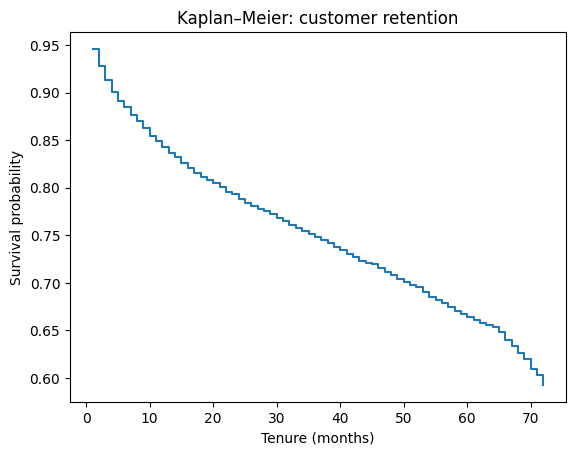

In [2]:
def km_curve(durations,events):
    d=pd.DataFrame({'t':durations,'e':events}).sort_values('t'); times=np.sort(d.loc[d.e==1,'t'].unique()); at_risk=len(d); S=1.0; out=[]
    for t in times:
        deaths=((d.t==t)&(d.e==1)).sum(); cens=((d.t==t)&(d.e==0)).sum(); S*=1-deaths/at_risk; out.append((t,S,at_risk,deaths)); at_risk-=deaths+cens
    return pd.DataFrame(out,columns=['time','survival','at_risk','events'])
km=km_curve(df.tenure,df.ChurnFlag); display(km.head())
fig,ax=plt.subplots(); ax.step(km.time,km.survival,where='post'); ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Survival probability'); ax.set_title('Kaplan–Meier: customer retention'); plt.show()

## 2. Contract-group survival curves

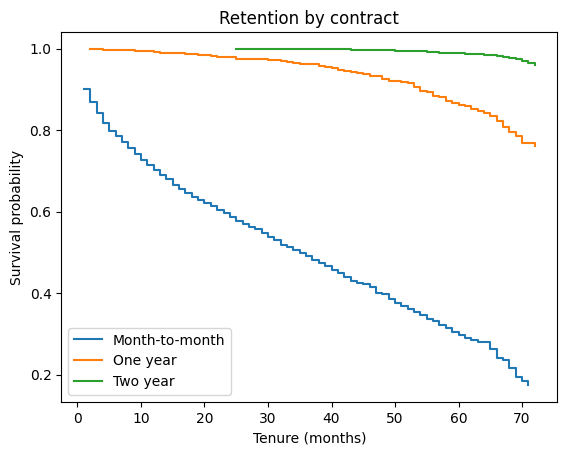

In [3]:
for contract,g in df.groupby('Contract'):
    k=km_curve(g.tenure,g.ChurnFlag); plt.step(k.time,k.survival,where='post',label=contract)
plt.xlabel('Tenure (months)'); plt.ylabel('Survival probability'); plt.legend(); plt.title('Retention by contract'); plt.show()

## 3. Cox proportional hazards regression

In [4]:
import statsmodels.api as sm
from statsmodels.duration.hazard_regression import PHReg
cox=df[['tenure','ChurnFlag','MonthlyCharges','SeniorCitizen','Partner','Dependents']].copy()
for c in ['Partner','Dependents']: cox[c]=(cox[c]=='Yes').astype(int)
cox['MonthlyCharges_z']=(cox.MonthlyCharges-cox.MonthlyCharges.mean())/cox.MonthlyCharges.std()
fit=PHReg(cox.tenure,cox[['MonthlyCharges_z','SeniorCitizen','Partner','Dependents']],status=cox.ChurnFlag).fit(disp=0)
print(fit.summary()); print('Hazard ratios:',np.exp(fit.params))

                            Results: PHReg
Model:                        PH Reg          Sample size:         7032
Dependent variable:           tenure          Num. events:         1869
Ties:                         Breslow                                  
-----------------------------------------------------------------------
                  log HR log HR SE   HR      t     P>|t|  [0.025 0.975]
-----------------------------------------------------------------------
MonthlyCharges_z  0.1657    0.0248 1.1803   6.6851 0.0000 1.1243 1.2390
SeniorCitizen     0.3862    0.0555 1.4715   6.9596 0.0000 1.3198 1.6405
Partner          -0.8605    0.0540 0.4229 -15.9422 0.0000 0.3805 0.4701
Dependents       -0.3745    0.0684 0.6877  -5.4783 0.0000 0.6014 0.7862
Confidence intervals are for the hazard ratios
Hazard ratios: [1.1802565  1.47145192 0.42293463 0.68765958]
